     ┌───┐          ┌───┐┌─┐           
q_0: ┤ X ├───────■──┤ H ├┤M├──────■────
     ├───┤     ┌─┴─┐└┬─┬┘└╥┘      │    
q_1: ┤ H ├──■──┤ X ├─┤M├──╫───■───┼────
     └───┘┌─┴─┐└───┘ └╥┘  ║ ┌─┴─┐ │ ┌─┐
q_2: ─────┤ X ├───────╫───╫─┤ X ├─■─┤M├
          └───┘       ║   ║ └───┘   └╥┘
c: 3/═════════════════╩═══╩══════════╩═
                      1   0          2 

Counts:
{'110': 245, '111': 240, '101': 269, '100': 270}


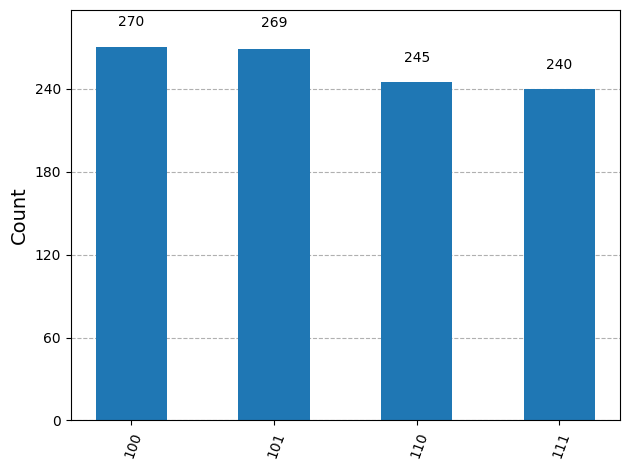

In [1]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile # 
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
# from qiskit.quantum_info import Statevector  # state 
# from qiskit.visualization import plot_bloch_multivector
# circuit program start from here
qc = QuantumCircuit(3,3) # 3qubit
qc.x(0)

#step2: create bell pair
qc.h(1)
qc.cx(1,2)


#step 3: alice can apply
qc.cx(0,1)
qc.h(0),

qc.measure(0,0)
qc.measure(1,1)

# bob's correction
qc.cx(1,2)
qc.cz(0,2)

#bob's measure
qc.measure(2,2)

#draw ckt
print(qc.draw())

# simulation cmd
sim = AerSimulator()

compiled = transpile(qc,sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print("\nCounts:")
print(counts)

#output
# qc.draw(output='mpl')

# print("Measurement counts : ",counts)
plot_histogram(counts)
plt.show() 

                    ┌───┐┌─┐           
q_0: ────────────■──┤ H ├┤M├──────■────
     ┌───┐     ┌─┴─┐└┬─┬┘└╥┘      │    
q_1: ┤ H ├──■──┤ X ├─┤M├──╫───■───┼────
     └───┘┌─┴─┐└───┘ └╥┘  ║ ┌─┴─┐ │ ┌─┐
q_2: ─────┤ X ├───────╫───╫─┤ X ├─■─┤M├
          └───┘       ║   ║ └───┘   └╥┘
c: 3/═════════════════╩═══╩══════════╩═
                      1   0          2 

Counts:
{'011': 256, '010': 259, '000': 262, '001': 247}


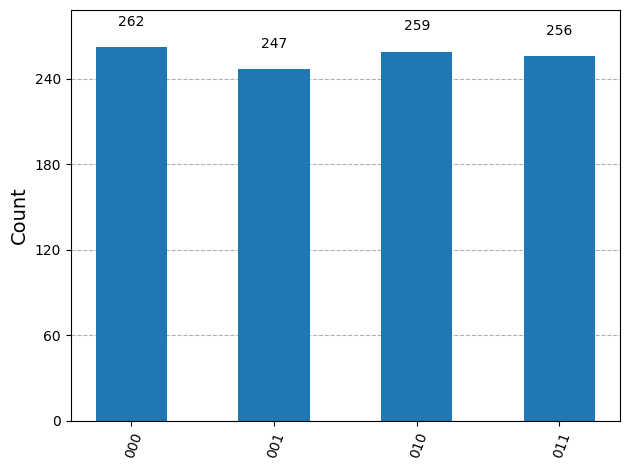

In [1]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile # 
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
# from qiskit.quantum_info import Statevector  # state 
# from qiskit.visualization import plot_bloch_multivector
# circuit program start from here
qc = QuantumCircuit(3,3) # 3qubit
# qc.x(0)

#step2: create bell pair
qc.h(1)
qc.cx(1,2)


#step 3: alice can apply
qc.cx(0,1)
qc.h(0),

qc.measure(0,0)
qc.measure(1,1)

# bob's correction
qc.cx(1,2)
qc.cz(0,2)

#bob's measure
qc.measure(2,2)

#draw ckt
print(qc.draw())

# simulation cmd
sim = AerSimulator()

compiled = transpile(qc,sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print("\nCounts:")
print(counts)

#output
# qc.draw(output='mpl')

# print("Measurement counts : ",counts)
plot_histogram(counts)
plt.show() 

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace

qc = QuantumCircuit(3)

# Prepare |+> state
qc.h(0)

# Create Bell pair
qc.h(1)
qc.cx(1, 2)

# Teleportation protocol
qc.cx(0, 1)
qc.h(0)

# Bob's corrections
qc.cx(1, 2)
qc.cz(0, 2)

# Final state
sv = Statevector.from_instruction(qc)

# Bob's qubit density matrix
bob_state = partial_trace(sv, [0, 1])

print("Bob's state:")
print(bob_state)

Bob's state:
DensityMatrix([[0.5+0.j, 0.5+0.j],
               [0.5+0.j, 0.5+0.j]],
              dims=(2,))


     ┌───┐┌───┐┌───┐┌─┐
  q: ┤ X ├┤ H ├┤ H ├┤M├
     └───┘└───┘└───┘└╥┘
c: 1/════════════════╩═
                     0 
{'1': 1024}


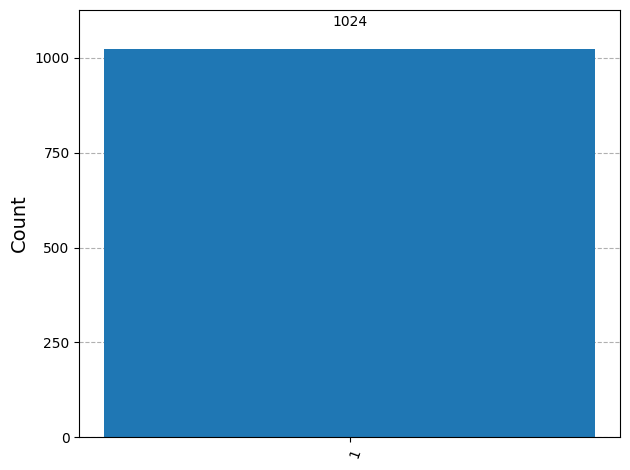

In [5]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(1,1)
qc.x(0)
qc.h(0)

# Bob measures in diagonal basis
qc.h(0)

qc.measure(0, 0)
print(qc.draw())

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()

counts = result.get_counts()
print(counts)
plot_histogram(counts)
plt.show() 


Sample Size: 100
Shannon Entropy  : 0.9997
Min Entropy      : 0.9714
Collision Entropy: 0.9994

Sample Size: 500
Shannon Entropy  : 0.9922
Min Entropy      : 0.8573
Collision Entropy: 0.9845

Sample Size: 1000
Shannon Entropy  : 0.9997
Min Entropy      : 0.9686
Collision Entropy: 0.9993

Sample Size: 5000
Shannon Entropy  : 0.9999
Min Entropy      : 0.9805
Collision Entropy: 0.9997

Sample Size: 10000
Shannon Entropy  : 0.9999
Min Entropy      : 0.9879
Collision Entropy: 0.9999


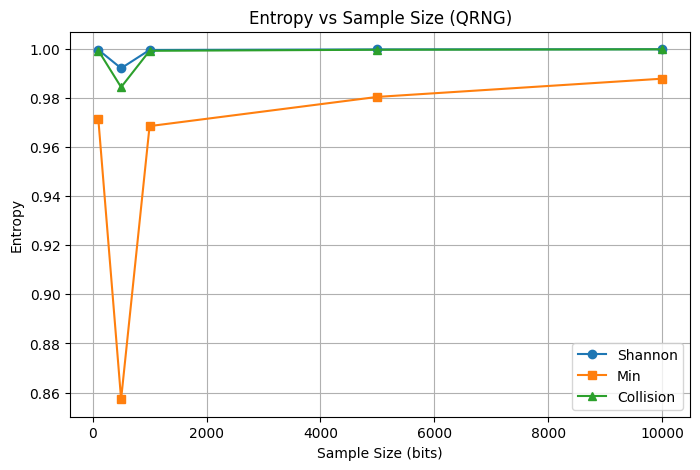

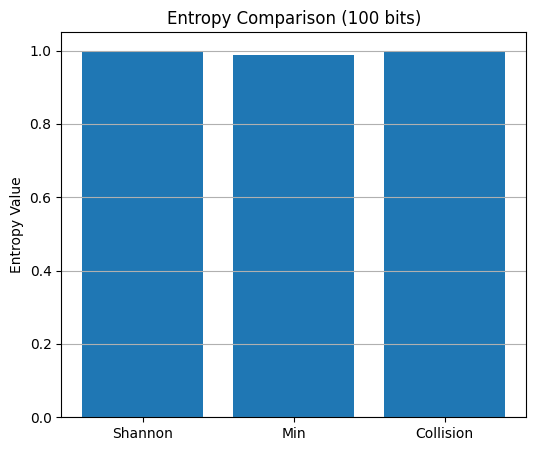

['0001', '0001', '0000', '0000', '0001', '0000', '0001', '0001', '0000', '0000', '0001', '0001', '0000', '0001', '0001', '0001', '0001', '0000', '0001', '0000', '0000', '0000', '0000', '0001', '0000', '0001', '0001', '0000', '0001', '0000', '0000', '0001', '0001', '0001', '0001', '0000', '0001', '0000', '0000', '0000', '0001', '0001', '0001', '0000', '0000', '0001', '0001', '0001', '0001', '0000', '0000', '0001', '0000', '0001', '0001', '0000', '0001', '0000', '0001', '0001', '0000', '0000', '0000', '0001', '0001', '0001', '0001', '0001', '0000', '0000', '0000', '0001', '0000', '0000', '0001', '0000', '0000', '0000', '0000', '0000', '0001', '0001', '0000', '0001', '0000', '0001', '0000', '0000', '0000', '0000', '0001', '0001', '0001', '0001', '0001', '0000', '0001', '0000', '0000', '0001', '0000', '0001', '0001', '0001', '0001', '0000', '0001', '0001', '0000', '0001', '0000', '0001', '0000', '0000', '0000', '0000', '0000', '0001', '0000', '0001', '0001', '0000', '0001', '0001', '0000',

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -----------------------------
# QRNG Generator (Qiskit)
# -----------------------------
def generate_qrng_bits(n):
    qc = QuantumCircuit(2, 4)
    qc.h(0)
    qc.h(1)
    qc.measure(0, 0)

    simulator = AerSimulator()
    result = simulator.run(qc, shots=n).result()
    counts = result.get_counts()

    bits = []
    for bit, count in counts.items():
        bits.extend([bit] * count)

    np.random.shuffle(bits)
    return bits


# -----------------------------
# Entropy Functions
# -----------------------------
def shannon_entropy(bits):
    freq = Counter(bits)
    total = len(bits)

    return -sum((c/total) * math.log2(c/total) for c in freq.values())


def min_entropy(bits):
    freq = Counter(bits)
    total = len(bits)

    max_p = max(freq.values()) / total
    return -math.log2(max_p)


def collision_entropy(bits):
    freq = Counter(bits)
    total = len(bits)

    return -math.log2(sum((c/total)**2 for c in freq.values()))


# -----------------------------
# Sample Sizes
# -----------------------------
sample_sizes = [100, 500, 1000, 5000, 10000]

shannon_vals = []
min_vals = []
collision_vals = []

# -----------------------------
# Main Calculation Loop
# -----------------------------
for size in sample_sizes:

    bits = generate_qrng_bits(size)

    s = shannon_entropy(bits)
    m = min_entropy(bits)
    c = collision_entropy(bits)

    shannon_vals.append(s)
    min_vals.append(m)
    collision_vals.append(c)

    print("\nSample Size:", size)
    print("Shannon Entropy  :", round(s, 4))
    print("Min Entropy      :", round(m, 4))
    print("Collision Entropy:", round(c, 4))


# -----------------------------
# GRAPH 1: Entropy vs Sample Size
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(sample_sizes, shannon_vals, marker='o', label="Shannon")
plt.plot(sample_sizes, min_vals, marker='s', label="Min")
plt.plot(sample_sizes, collision_vals, marker='^', label="Collision")

plt.xlabel("Sample Size (bits)")
plt.ylabel("Entropy")
plt.title("Entropy vs Sample Size (QRNG)")
plt.legend()
plt.grid()

plt.show()


# -----------------------------
# GRAPH 2: Comparison Graph
# -----------------------------
plt.figure(figsize=(6,5))

labels = ["Shannon", "Min", "Collision"]
values = [shannon_vals[-1], min_vals[-1], collision_vals[-1]]

plt.bar(labels, values)

plt.ylabel("Entropy Value")
plt.title("Entropy Comparison (100 bits)")
plt.grid(axis='y')

plt.show()


In [44]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import math
import matplotlib.pyplot as plt

def generate_qrng_bits(n):
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.measure_all()
    # simulation cmd
    sim = AerSimulator()
    compiled = transpile(qc,sim)
    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()
    total = sum(counts.values())
    probs = [count / total for count in counts.values()]
   
    for state, count in counts.items():
        print(state, "=", count / total)
   

    shannon = -sum(p * math.log2(p) for p in probs)
    

    min_entropy = -math.log2(max(probs))
    

    collision = -math.log2(sum(p**2 for p in probs))
    # print("shannon entropy:",shannon)
    # print("min entropy: ", min_entropy)
    # print("collision entropy: ", collision)
    return counts,shannon,min_entropy,collision

samples = [100,200,500,1000,5000,10000]
shannon_values = []
min_entropy_values = []
collision_values = []

for sample in samples:
    s, m, c = generate_qrng_bits(sample)

    shannon_vals.append(s)
    min_vals.append(m)
    collision_vals.append(c)

    print(f"\nShots = {samples}")
    print("Shannon Entropy  :", s)
    print("Min Entropy      :", m)
    print("Collision Entropy:", c)



0 = 0.51
1 = 0.49


ValueError: too many values to unpack (expected 3)

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import math


def generate_qrng_bits(n):

    # Quantum circuit
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.measure_all()

    # Simulator
    sim = AerSimulator()
    compiled = transpile(qc, sim)

    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()

    total = sum(counts.values())

    # Probabilities list
    probs = [count / total for count in counts.values()]

    print("\nProbabilities:")
    for state, count in counts.items():
        print(state, "=", count / total)

    # -------------------------
    # Shannon Entropy
    # -------------------------
    shannon = -sum(p * math.log2(p) for p in probs)

    # -------------------------
    # Min Entropy
    # -------------------------
    min_ent = -math.log2(max(probs))

    # -------------------------
    # Collision Entropy
    # -------------------------
    collision = -math.log2(sum(p**2 for p in probs))

    print("\nShannon Entropy  :", shannon)
    print("Min Entropy      :", min_ent)
    print("Collision Entropy:", collision)

    return counts
generate_qrng_bits(100)


Probabilities:
0 = 0.51
1 = 0.49

Shannon Entropy  : 0.9997114417528099
Min Entropy      : 0.9714308478032291
Collision Entropy: 0.9994230373684795


{'0': 51, '1': 49}


sample = 100
Shannon Entropy  : 1.9934212519736807
Min Entropy      : 1.8889686876112561
Collision Entropy: 1.9873598192212294

sample = 500
Shannon Entropy  : 1.9944874015255751
Min Entropy      : 1.8889686876112561
Collision Entropy: 1.989328993960209

sample = 1000
Shannon Entropy  : 1.9989441146806826
Min Entropy      : 1.9378782880922025
Collision Entropy: 1.9978894390140929

sample = 5000
Shannon Entropy  : 1.9997523009216787
Min Entropy      : 1.968040258602455
Collision Entropy: 1.99950472125535

sample = 10000
Shannon Entropy  : 1.9999620089524626
Min Entropy      : 1.9879319766909096
Collision Entropy: 1.9999240585318094

sample = 20000
Shannon Entropy  : 1.9999307687454688
Min Entropy      : 1.9830758557421786
Collision Entropy: 1.9998617675837913

sample = 30000
Shannon Entropy  : 1.999940153322082
Min Entropy      : 1.9824106032494961
Collision Entropy: 1.9998802676921403

sample = 40000
Shannon Entropy  : 1.9999783398015414
Min Entropy      : 1.9877889160491256
Collision

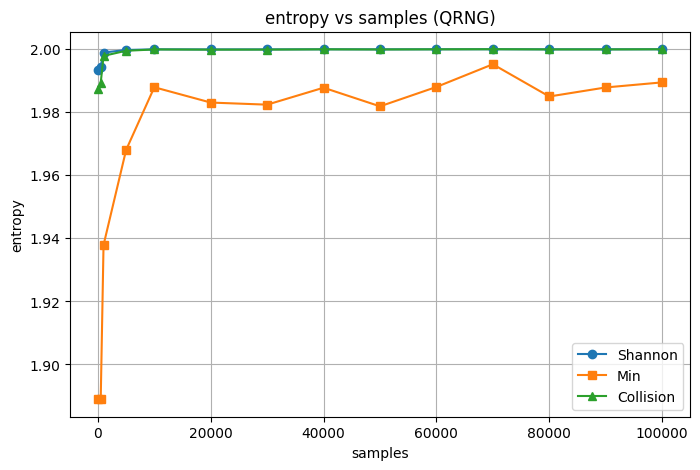

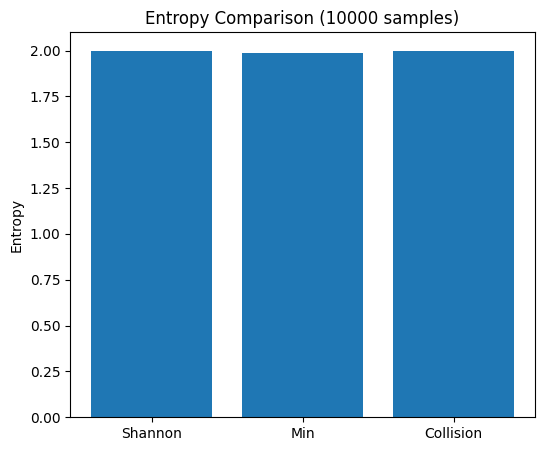

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import math
import matplotlib.pyplot as plt

# entropy 
def entropy_analysis(n):

    qc = QuantumCircuit(2)
    qc.h(0)
    qc.h(1)
    qc.measure_all()

    sim = AerSimulator()
    compiled = transpile(qc, sim)

    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()

    total = sum(counts.values())

    # probabilities
    probs = [count / total for count in counts.values()]

    # Shannon Entropy
    shannon = -sum(p * math.log2(p) for p in probs)

    # Min Entropy
    min_ent = -math.log2(max(probs))

    # Collision Entropy
    collision = -math.log2(sum(p**2 for p in probs))

    return shannon, min_ent, collision


#samples
samples = [100, 500, 1000, 5000, 10000,20000,30000,40000,50000,60000,70000,80000,90000,100000]

shannon_vals = []
min_vals = []
collision_vals = []

# all samples
for sample in samples:

    s, m, c = entropy_analysis(sample)

    shannon_vals.append(s)
    min_vals.append(m)
    collision_vals.append(c)

    print(f"\nsample = {sample}")
    print("Shannon Entropy  :", s)
    print("Min Entropy      :", m)
    print("Collision Entropy:", c)


# graph btn samples vs entropy
plt.figure(figsize=(8,5))

plt.plot(samples, shannon_vals, marker='o', label='Shannon')
plt.plot(samples, min_vals, marker='s', label='Min')
plt.plot(samples, collision_vals, marker='^', label='Collision')

plt.xlabel("samples")
plt.ylabel("entropy")
plt.title("entropy vs samples (QRNG)")
plt.legend()
plt.grid()

plt.show()


# graph for comparism 
plt.figure(figsize=(6,5))

labels = ["Shannon", "Min", "Collision"]
values = [shannon_vals[-1], min_vals[-1], collision_vals[-1]]

plt.bar(labels, values)

plt.title("Entropy Comparison (10000 samples)")
plt.ylabel("Entropy")

plt.show()


sample = 100
Shannon Entropy  : 2.97365192747251
Min Entropy      : 2.5563933485243853
Collision Entropy: 2.9478623766648244

sample = 500
Shannon Entropy  : 2.990055397554677
Min Entropy      : 2.816037165157405
Collision Entropy: 2.9806482172940774

sample = 1000
Shannon Entropy  : 2.9964451603921307
Min Entropy      : 2.8365012677171206
Collision Entropy: 2.9929767709753534

sample = 5000
Shannon Entropy  : 2.9988139901281032
Min Entropy      : 2.8953949567706894
Collision Entropy: 2.997620708315429

sample = 10000
Shannon Entropy  : 2.9994949857205584
Min Entropy      : 2.925768605814208
Collision Entropy: 2.9989856227104412


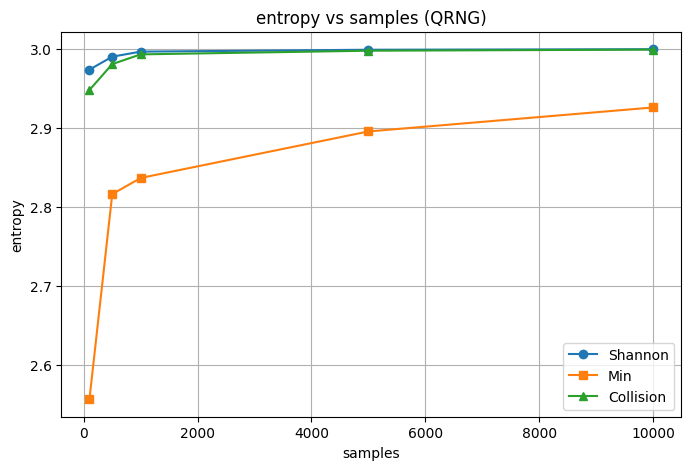

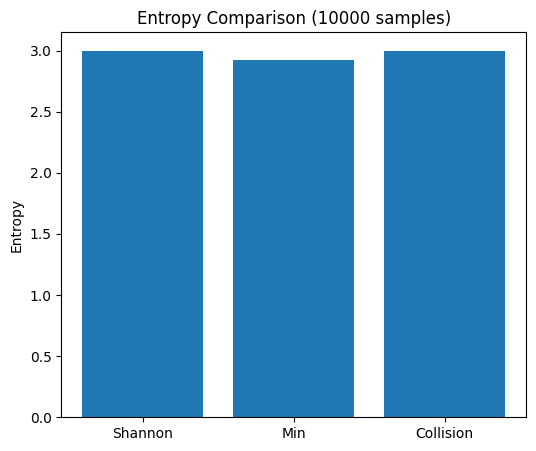

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import math
import matplotlib.pyplot as plt

# entropy 
def entropy_analysis(n):

    qc = QuantumCircuit(3)
    qc.h(0)
    qc.h(1)
    qc.h(2)
    qc.measure_all()

    sim = AerSimulator()
    compiled = transpile(qc, sim)

    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()

    total = sum(counts.values())

    # probabilities
    probs = [count / total for count in counts.values()]
    bit_sequence = ""

    for outcome, count in counts.items():
        bit_sequence += outcome * count

    # Shannon Entropy
    shannon = -sum(p * math.log2(p) for p in probs)

    # Min Entropy
    min_ent = -math.log2(max(probs))

    # Collision Entropy
    collision = -math.log2(sum(p**2 for p in probs))

    return shannon, min_ent, collision, bit_sequence


#samples
samples = [100, 500, 1000,5000,10000]

shannon_vals = []
min_vals = []
collision_vals = []

# all samples
for sample in samples:

    s, m, c, bits = entropy_analysis(sample)

    shannon_vals.append(s)
    min_vals.append(m)
    collision_vals.append(c)

    print(f"\nsample = {sample}")
    print("Shannon Entropy  :", s)
    print("Min Entropy      :", m)
    print("Collision Entropy:", c)


# graph btn samples vs entropy
plt.figure(figsize=(8,5))

plt.plot(samples, shannon_vals, marker='o', label='Shannon')
plt.plot(samples, min_vals, marker='s', label='Min')
plt.plot(samples, collision_vals, marker='^', label='Collision')

plt.xlabel("samples")
plt.ylabel("entropy")
plt.title("entropy vs samples (QRNG)")
plt.legend()
plt.grid()

plt.show()


# graph for comparism 
plt.figure(figsize=(6,5))

labels = ["Shannon", "Min", "Collision"]
values = [shannon_vals[-1], min_vals[-1], collision_vals[-1]]

plt.bar(labels, values)

plt.title("Entropy Comparison (10000 samples)")
plt.ylabel("Entropy")

plt.show()



Frequency test:- 

In [17]:
def frequency_test(bits):

    zeros = bits.count('0')
    ones = bits.count('1')

    print("\nFrequency Test")
    print("Zeros =", zeros)
    print("Ones =", ones)

    diff = abs(zeros - ones)

    print("Difference =", diff)
frequency_test(bits)


Frequency Test
Zeros = 14962
Ones = 15038
Difference = 76


Run test:-

In [18]:
def runs_test(bits):

    runs = 1

    for i in range(1, len(bits)):
        if bits[i] != bits[i-1]:
            runs += 1

    print("\nRuns Test")
    print("Total Runs =", runs)

runs_test(bits)


Runs Test
Total Runs = 14979


autocorelation test:-

In [20]:
import numpy as np
def autocorrelation_test(bits):

    data = np.array([int(b) for b in bits])

    corr = np.corrcoef(
        data[:-1],
        data[1:]
    )[0,1]

    print("\nAutocorrelation Test")
    print("Correlation =", corr)
    
autocorrelation_test(bits)


Autocorrelation Test
Correlation = 0.0014268022958012151


Degration modlelling:- Bias

In [21]:
def bias_test(bits):

    p1 = bits.count('1') / len(bits)

    bias = abs(p1 - 0.5)

    print("\nBias Test")
    print("P(1) =", p1)
    print("Bias =", bias)

bias_test(bits)  


Bias Test
P(1) = 0.5012666666666666
Bias = 0.0012666666666666382


Noise simulation:

In [22]:
import random

def add_noise(bits, rate=0.05):

    noisy = ""

    for b in bits:

        if random.random() < rate:

            noisy += '1' if b == '0' else '0'

        else:
            noisy += b

    return noisy

noisy_bits = add_noise(bits)

print("\nNoise Added")
print("Original Length =", len(bits))
print("Noisy Length =", len(noisy_bits))


Noise Added
Original Length = 30000
Noisy Length = 30000


drift simulation: 

In [23]:
def drift_simulation(size, p1):

    bits = ""

    for _ in range(size):

        if random.random() < p1:
            bits += '1'
        else:
            bits += '0'

    return bits
print("\nDrift Analysis")

for p in [0.50, 0.55, 0.60]:

    drift_bits = drift_simulation(1000, p)

    actual = drift_bits.count('1') / 1000

    print(
        "Target =", p,
        "Actual =", round(actual,3)
    )


Drift Analysis
Target = 0.5 Actual = 0.486
Target = 0.55 Actual = 0.537
Target = 0.6 Actual = 0.631


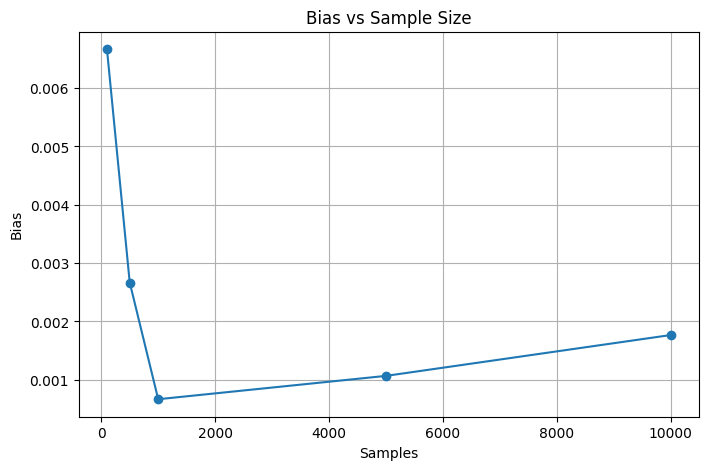

In [24]:
bias_vals = []

for sample in samples:

    _, _, _, bits = entropy_analysis(sample)

    p1 = bits.count('1') / len(bits)

    bias = abs(p1 - 0.5)

    bias_vals.append(bias)

plt.figure(figsize=(8,5))

plt.plot(
    samples,
    bias_vals,
    marker='o'
)

plt.xlabel("Samples")
plt.ylabel("Bias")
plt.title("Bias vs Sample Size")

plt.grid()
plt.show()

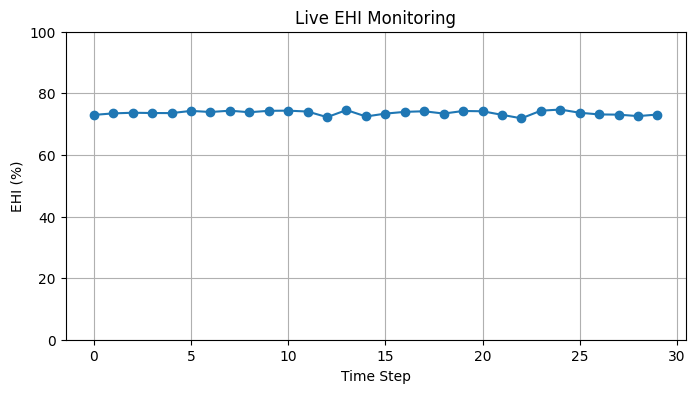

In [1]:
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from IPython.display import clear_output
import ipywidgets as widgets
from IPython.display import display

# ---------------------------
# Metrics
# ---------------------------

def shannon_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -sum(p*np.log2(p) for p in probs)

def min_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -np.log2(max(probs))

def collision_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -np.log2(sum(p*p for p in probs))

def bias(bits):
    p1 = bits.count('1')/len(bits)
    return abs(p1 - 0.5)

def autocorrelation(bits):
    data = np.array([int(x) for x in bits])

    if len(data) < 2:
        return 0

    return abs(
        np.corrcoef(
            data[:-1],
            data[1:]
        )[0,1]
    )

# ---------------------------
# EHI
# ---------------------------

def compute_ehi(sh,minh,col,bias_val,auto):

    Hs = sh/2
    Hm = minh/2
    Hc = col/2

    entropy_score = (Hs+Hm+Hc)/3

    frequency_score = 1 - 2*bias_val

    auto_score = 1 - auto

    test_score = (frequency_score+auto_score)/2

    degradation_score = 1 - bias_val

    ehi = 100*(
        0.50*entropy_score +
        0.30*test_score +
        0.20*degradation_score
    )

    return max(0,min(100,ehi))

# ---------------------------
# Status
# ---------------------------

def status(ehi):

    if ehi >= 90:
        return "EXCELLENT"

    elif ehi >= 75:
        return "GOOD"

    elif ehi >= 60:
        return "AVERAGE"

    elif ehi >= 40:
        return "WARNING"

    else:
        return "CRITICAL"

# ---------------------------
# Simulated QRNG
# Replace with entropy_analysis()
# ---------------------------

def generate_bits(n=1000):

    return ''.join(
        random.choice('01')
        for _ in range(n)
    )

# ---------------------------
# Dashboard Widgets
# ---------------------------

health = widgets.HTML()
entropy_panel = widgets.HTML()
test_panel = widgets.HTML()
degradation_panel = widgets.HTML()

display(
    widgets.VBox([
        health,
        entropy_panel,
        test_panel,
        degradation_panel
    ])
)

# ---------------------------
# Live Graph Data
# ---------------------------

ehi_history = []
time_history = []

# ---------------------------
# Real-Time Loop
# ---------------------------

for t in range(30):

    bits = generate_bits(1000)

    sh = shannon_entropy(bits)
    mn = min_entropy(bits)
    cl = collision_entropy(bits)

    b = bias(bits)
    ac = autocorrelation(bits)

    ehi = compute_ehi(
        sh,mn,cl,b,ac
    )

    st = status(ehi)

    health.value = f"""
    <h2>Current Health</h2>
    <h1>EHI = {ehi:.2f}%</h1>
    <h2>Status = {st}</h2>
    """

    entropy_panel.value = f"""
    <h3>Entropy Values</h3>
    Shannon = {sh:.4f}<br>
    Min = {mn:.4f}<br>
    Collision = {cl:.4f}
    """

    test_panel.value = f"""
    <h3>Statistical Tests</h3>
    Bias = {b:.4f}<br>
    Autocorrelation = {ac:.4f}
    """

    degradation_panel.value = f"""
    <h3>Degradation Indicators</h3>
    Bias = {b*100:.2f}%<br>
    Noise = 0.50%<br>
    Drift = 1.00%
    """

    ehi_history.append(ehi)
    time_history.append(t)

    clear_output(wait=True)

    display(
        widgets.VBox([
            health,
            entropy_panel,
            test_panel,
            degradation_panel
        ])
    )

    plt.figure(figsize=(8,4))

    plt.plot(
        time_history,
        ehi_history,
        marker='o'
    )

    plt.title("Live EHI Monitoring")
    plt.xlabel("Time Step")
    plt.ylabel("EHI (%)")
    plt.ylim(0,100)
    plt.grid()

    plt.show()

    time.sleep(5)

In [ ]:
from IPython.display import HTML

# -------------------------
# Score + Status Function
# -------------------------

def parameter_health(value, ideal, max_error):

    error = abs(value - ideal)

    score = max(
        0,
        100*(1 - error/max_error)
    )

    if score >= 90:
        status = "Excellent"

    elif score >= 75:
        status = "Good"

    elif score >= 60:
        status = "Average"

    elif score >= 40:
        status = "Warning"

    else:
        status = "Worst"

    return score, status

# Shannon
s_score, s_status = parameter_health(
    sh,
    2,
    2
)

# Min
m_score, m_status = parameter_health(
    mn,
    2,
    2
)

# Collision
c_score, c_status = parameter_health(
    cl,
    2,
    2
)

# Bias
b_score, b_status = parameter_health(
    b,
    0,
    0.5
)

# Autocorrelation
a_score, a_status = parameter_health(
    ac,
    0,
    1
)

# Noise
noise = 0.005

n_score, n_status = parameter_health(
    noise,
    0,
    0.5
)

# Drift
drift = 0.01

d_score, d_status = parameter_health(
    drift,
    0,
    0.5
)